1. Setup and Data Loading
We start with the reproducible Colab environment: mounting Google Drive or uploading the dataset. We set a random seed for reproducibility. The dataset (Customer Churn new.csv) can be uploaded via Colab's file upload or placed in Drive.

In [2]:
# Colab-specific setup: mount Drive or upload file
# Option 1: Mount Google Drive (if dataset is stored there)
# from google.colab import drive
# drive.mount('/content/drive')
# data_path = '/content/drive/MyDrive/Customer Churn new.csv'

# Option 2: Upload directly (uncomment if needed):
# from google.colab import files
# uploaded = files.upload()
# data_path = 'Customer Churn new.csv'

# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For resampling and modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

# Imbalanced-learn for SMOTE
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
df = pd.read_csv("Customer Churn new.csv")
#df = pd.read_csv(data_path)
print(f"Dataset loaded. Shape: {df.shape}")
df.head()


Dataset loaded. Shape: (10000, 11)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0


In [3]:
# Brief data inspection
print("Data types and null counts:")
display(df.info())
print("\nClass distribution in target 'Exited':")
print(df['Exited'].value_counts())


Data types and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


None


Class distribution in target 'Exited':
Exited
0    7963
1    2037
Name: count, dtype: int64


2. Data Preprocessing
We clean and prepare data:

Drop identifiers: Remove RowNumber, CustomerId, Surname as they are unique IDs.
Encode categories: Convert Geography and Gender to numeric labels.
Define features and target.

In [4]:
# Drop identifier columns
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['Geography'] = le.fit_transform(df_clean['Geography'])
df_clean['Gender']    = le.fit_transform(df_clean['Gender'])

# Separate features and target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

print(f"Features shape: {X.shape}, Target shape: {y.shape}")
display(X.head())


Features shape: (10000, 7), Target shape: (10000,)


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary
0,844,0,1,18,2,160980.03,145936.28
1,656,0,1,18,10,151762.74,127014.32
2,570,0,0,18,4,82767.42,71811.90
3,716,1,0,18,3,128743.80,197322.13
4,727,0,1,18,4,133550.67,46941.41


In [5]:
# Check for remaining issues (e.g., nulls, imbalances)
print("Any null values in features?", X.isnull().any().any())
print("Class counts:\n", y.value_counts())


Any null values in features? False
Class counts:
 Exited
0    7963
1    2037
Name: count, dtype: int64


3. Exploratory Data Analysis (EDA)
We visualize data to understand feature distributions and relationships before modeling:



/tmp/ipykernel_3587/3821372251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='muted')


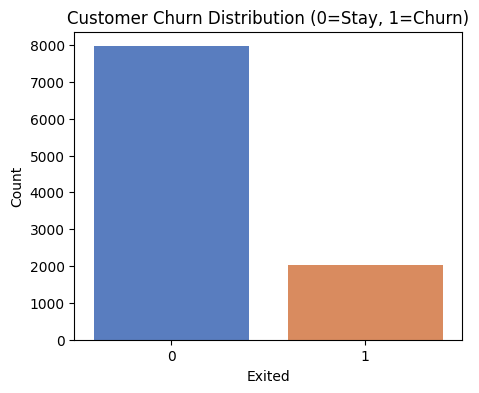

Churn (1) vs. Stay (0) counts: {0: 7963, 1: 2037}


In [6]:
# EDA Plot: Target class distribution
plt.figure(figsize=(5,4))
sns.countplot(x=y, palette='muted')
plt.title("Customer Churn Distribution (0=Stay, 1=Churn)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()
print("Churn (1) vs. Stay (0) counts:", y.value_counts().to_dict())


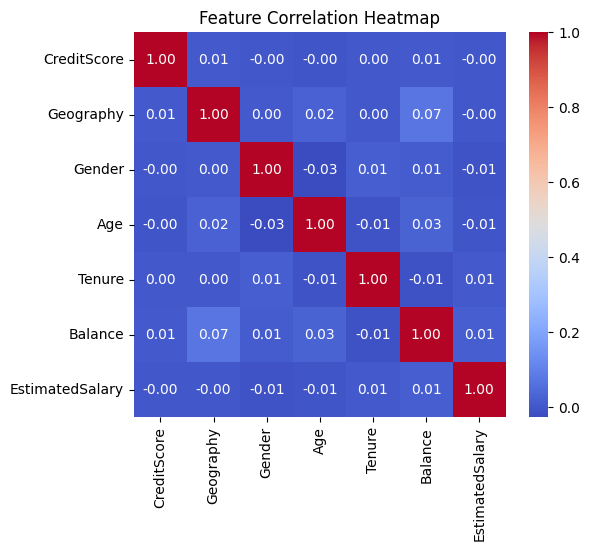

In [7]:
# EDA Plot: Correlation heatmap of features
plt.figure(figsize=(6,5))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


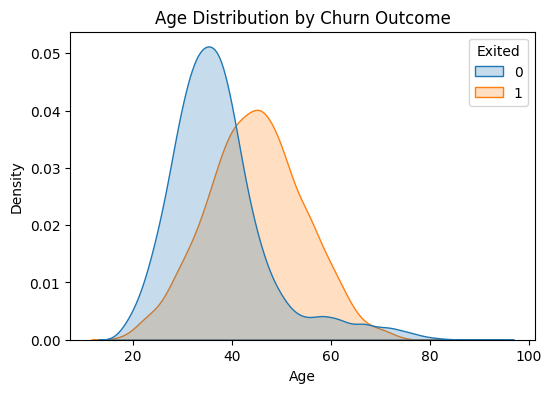

In [8]:
# EDA Plot: Age distribution by churn vs stay
plt.figure(figsize=(6,4))
sns.kdeplot(data=df_clean, x='Age', hue='Exited', fill=True, common_norm=False)
plt.title("Age Distribution by Churn Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()


4. Baseline Logistic Regression Model
We train a baseline logistic regression without addressing imbalance or tuning. We split data 80/20 and standardize features (logistic regression performs better on scaled data). Then we evaluate metrics on the test set.

In [9]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Baseline model: default logistic regression (L2 penalty, C=1.0, solver=lbfgs)
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_scaled, y_train)
print("Baseline logistic regression trained.")


Train size: 8000, Test size: 2000
Baseline logistic regression trained.


In [10]:
# Evaluate baseline model
y_pred = baseline_model.predict(X_test_scaled)
print("Baseline Model Classification Report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")


Baseline Model Classification Report:
              precision    recall  f1-score   support

           0      0.804     0.966     0.878      1593
           1      0.379     0.081     0.134       407

    accuracy                          0.786      2000
   macro avg      0.592     0.524     0.506      2000
weighted avg      0.718     0.786     0.726      2000

Accuracy: 0.786


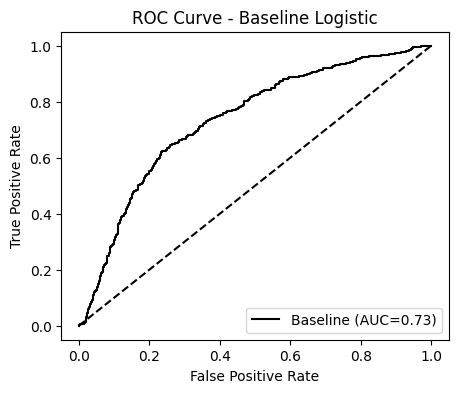

In [11]:
# Baseline model ROC curve and AUC
y_prob = baseline_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'Baseline (AUC={roc_auc:.2f})', color='black')
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Baseline Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()


5. Addressing Class Imbalance
The dataset is imbalanced, so we try two strategies:

Class weighting: Let LogisticRegression automatically weight classes inversely to frequency (class_weight='balanced'), as per scikit-learn docs
.
SMOTE oversampling: Use the SMOTE algorithm to synthetically generate minority-class examples
, balancing the training set.

In [12]:
# Model with class_weight='balanced'
cw_model = LogisticRegression(class_weight='balanced', random_state=42)
cw_model.fit(X_train_scaled, y_train)
y_pred_cw = cw_model.predict(X_test_scaled)
print("Class-Weighted Model Report:")
print(classification_report(y_test, y_pred_cw, digits=3))
print(f"Accuracy: {accuracy_score(y_test, y_pred_cw):.3f}")


Class-Weighted Model Report:
              precision    recall  f1-score   support

           0      0.895     0.719     0.797      1593
           1      0.379     0.671     0.484       407

    accuracy                          0.709      2000
   macro avg      0.637     0.695     0.641      2000
weighted avg      0.790     0.709     0.734      2000

Accuracy: 0.709


In [13]:
# Apply SMOTE to oversample training set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE, training class counts: {np.bincount(y_train_sm)}")

# Model trained on SMOTE-resampled data
sm_model = LogisticRegression(random_state=42)
sm_model.fit(X_train_sm, y_train_sm)
y_pred_sm = sm_model.predict(X_test_scaled)
print("SMOTE Oversampled Model Report:")
print(classification_report(y_test, y_pred_sm, digits=3))
print(f"Accuracy: {accuracy_score(y_test, y_pred_sm):.3f}")


After SMOTE, training class counts: [6370 6370]
SMOTE Oversampled Model Report:
              precision    recall  f1-score   support

           0      0.895     0.725     0.801      1593
           1      0.383     0.668     0.487       407

    accuracy                          0.714      2000
   macro avg      0.639     0.697     0.644      2000
weighted avg      0.791     0.714     0.737      2000

Accuracy: 0.714


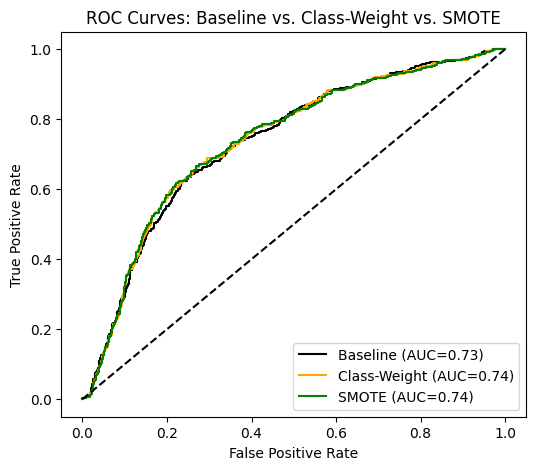

In [14]:
# Compare ROC curves of all models (Baseline, Class-Weight, SMOTE)
plt.figure(figsize=(6,5))
# Baseline
fpr, tpr, _ = roc_curve(y_test, baseline_model.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr, tpr, label=f"Baseline (AUC={auc(fpr,tpr):.2f})", color='black')
# Class-weight
fpr_cw, tpr_cw, _ = roc_curve(y_test, cw_model.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_cw, tpr_cw, label=f"Class-Weight (AUC={auc(fpr_cw,tpr_cw):.2f})", color='orange')
# SMOTE
fpr_sm, tpr_sm, _ = roc_curve(y_test, sm_model.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_sm, tpr_sm, label=f"SMOTE (AUC={auc(fpr_sm,tpr_sm):.2f})", color='green')

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves: Baseline vs. Class-Weight vs. SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()


6. Hyperparameter Tuning with GridSearchCV
We use GridSearchCV to find the best logistic regression hyperparameters (penalty, C, solver, class_weight) via 5-fold CV. This automates the search for regularization strength and class weights.

In [15]:
# Define parameter grid for GridSearchCV
param_grid = {
    'penalty': ['l2'],            # 'l1' requires solver='liblinear', here we use 'l2' penalty
    'C': [0.01, 0.1, 1, 10],      # Inverse regularization strength【18†L728-L732】
    'solver': ['lbfgs','liblinear','saga'],
    'class_weight': [None, 'balanced']
}
grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=500, random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',           # maximize AUC
    cv=5, n_jobs=-1, verbose=1
)
grid.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid.best_params_}, Best AUC (CV): {grid.best_score_:.3f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}, Best AUC (CV): 0.749


In [16]:
# Evaluate tuned model on the test set
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_best, digits=3))
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.3f}")


Tuned Model Classification Report:
              precision    recall  f1-score   support

           0      0.895     0.719     0.797      1593
           1      0.379     0.671     0.484       407

    accuracy                          0.709      2000
   macro avg      0.637     0.695     0.641      2000
weighted avg      0.790     0.709     0.734      2000

Accuracy: 0.709


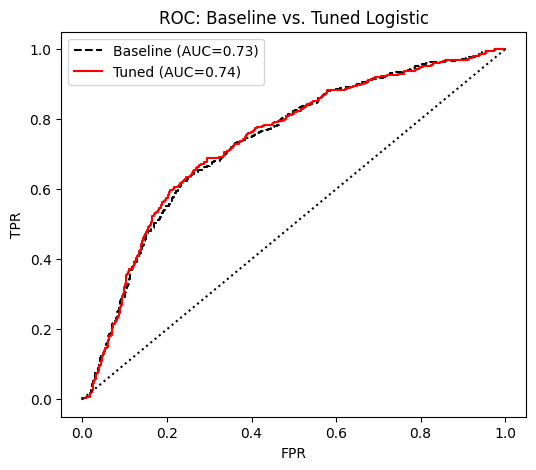

In [17]:
# Include tuned model in ROC comparison
fpr_best, tpr_best, _ = roc_curve(y_test, best_model.predict_proba(X_test_scaled)[:,1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='black', linestyle='--', label=f"Baseline (AUC={auc(fpr,tpr):.2f})")
plt.plot(fpr_best, tpr_best, color='red', label=f"Tuned (AUC={auc(fpr_best,tpr_best):.2f})")
plt.plot([0,1],[0,1],'k:')
plt.title("ROC: Baseline vs. Tuned Logistic")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


7. Cross-Validation Evaluation
To assess model stability, we perform k-fold cross-validation and report mean ± std of key metrics (accuracy, precision, recall, AUC). We use 5-fold CV on the training data for consistency.

In [19]:
cv = 5
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'roc_auc']
# Baseline CV
scores_base = cross_validate(baseline_model, X_train_scaled, y_train, cv=cv, scoring=scoring)
# Class-weight CV
scores_cw   = cross_validate(cw_model, X_train_scaled, y_train, cv=cv, scoring=scoring)
# SMOTE pipeline CV (resample inside each fold)
# We use a custom approach since cross_validate doesn't support resampling directly:
from sklearn.base import clone

def cross_val_smote(model, X, y, cv):
    accuracies = []
    precisions = []
    recalls = []
    aucs = []
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        X_tr_res, y_tr_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
        m = clone(model).fit(X_tr_res, y_tr_res)
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:,1]
        accuracies.append(accuracy_score(y_te, y_pred))
        precisions.append(precision := (classification_report(y_te, y_pred, output_dict=True)['macro avg']['precision']))
        recalls.append(recall := (classification_report(y_te, y_pred, output_dict=True)['macro avg']['recall']))
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        aucs.append(auc(fpr, tpr))
    return np.array(accuracies), np.array(precisions), np.array(recalls), np.array(aucs)

# Perform SMOTE CV
acc_sm, prec_sm, rec_sm, auc_sm = cross_val_smote(LogisticRegression(random_state=42), X_train_scaled, y_train.values, cv)
# Tuned model CV (with best params)
scores_best = cross_validate(best_model, X_train_scaled, y_train, cv=cv, scoring=scoring)

# Summarize CV results
import numpy as np
cv_results = pd.DataFrame({
    'Model': ['Baseline', 'Class-Weight', 'SMOTE', 'Tuned'],
    'Accuracy (mean±std)': [
        f"{scores_base['test_accuracy'].mean():.3f}±{scores_base['test_accuracy'].std():.3f}",
        f"{scores_cw['test_accuracy'].mean():.3f}±{scores_cw['test_accuracy'].std():.3f}",
        f"{acc_sm.mean():.3f}±{acc_sm.std():.3f}",
        f"{scores_best['test_accuracy'].mean():.3f}±{scores_best['test_accuracy'].std():.3f}"
    ],
    'Precision (mean±std)': [
        f"{scores_base['test_precision_macro'].mean():.3f}±{scores_base['test_precision_macro'].std():.3f}",
        f"{scores_cw['test_precision_macro'].mean():.3f}±{scores_cw['test_precision_macro'].std():.3f}",
        f"{prec_sm.mean():.3f}±{prec_sm.std():.3f}",
        f"{scores_best['test_precision_macro'].mean():.3f}±{scores_best['test_precision_macro'].std():.3f}"
    ],
    'Recall (mean±std)': [
        f"{scores_base['test_recall_macro'].mean():.3f}±{scores_base['test_recall_macro'].std():.3f}",
        f"{scores_cw['test_recall_macro'].mean():.3f}±{scores_cw['test_recall_macro'].std():.3f}",
        f"{rec_sm.mean():.3f}±{rec_sm.std():.3f}",
        f"{scores_best['test_recall_macro'].mean():.3f}±{scores_best['test_recall_macro'].std():.3f}"
    ],
    'ROC AUC (mean±std)': [
        f"{scores_base['test_roc_auc'].mean():.3f}±{scores_base['test_roc_auc'].std():.3f}",
        f"{scores_cw['test_roc_auc'].mean():.3f}±{scores_cw['test_roc_auc'].std():.3f}",
        f"{auc_sm.mean():.3f}±{auc_sm.std():.3f}",
        f"{scores_best['test_roc_auc'].mean():.3f}±{scores_best['test_roc_auc'].std():.3f}"
    ]
})
display(cv_results)


,Model,Accuracy (mean±std),Precision (mean±std),Recall (mean±std),ROC AUC (mean±std)
0,Baseline,0.785±0.003,0.594±0.009,0.527±0.005,0.745±0.012
1,Class-Weight,0.707±0.010,0.637±0.011,0.695±0.017,0.749±0.012
2,SMOTE,0.710±0.006,0.639±0.010,0.699±0.017,0.750±0.016
3,Tuned,0.707±0.010,0.637±0.011,0.695±0.017,0.749±0.012


8. Model Comparison
We summarize and compare models in a table and bar chart:

In [20]:
# Aggregate test-set metrics and best params into a summary table
models = ['Baseline', 'Class-Weight', 'SMOTE', 'Tuned']
accuracies = [accuracy_score(y_test, baseline_model.predict(X_test_scaled)),
              accuracy_score(y_test, cw_model.predict(X_test_scaled)),
              accuracy_score(y_test, sm_model.predict(X_test_scaled)),
              accuracy_score(y_test, best_model.predict(X_test_scaled))]
precisions = [precision := (classification_report(y_test, baseline_model.predict(X_test_scaled), output_dict=True)['macro avg']['precision']),
              (classification_report(y_test, cw_model.predict(X_test_scaled), output_dict=True)['macro avg']['precision']),
              (classification_report(y_test, sm_model.predict(X_test_scaled), output_dict=True)['macro avg']['precision']),
              (classification_report(y_test, best_model.predict(X_test_scaled), output_dict=True)['macro avg']['precision'])]
recalls = [(classification_report(y_test, baseline_model.predict(X_test_scaled), output_dict=True)['macro avg']['recall']),
           (classification_report(y_test, cw_model.predict(X_test_scaled), output_dict=True)['macro avg']['recall']),
           (classification_report(y_test, sm_model.predict(X_test_scaled), output_dict=True)['macro avg']['recall']),
           (classification_report(y_test, best_model.predict(X_test_scaled), output_dict=True)['macro avg']['recall'])]
aucs = [auc(fpr, tpr),
        auc(fpr_cw, tpr_cw),
        auc(fpr_sm, tpr_sm),
        auc(fpr_best, tpr_best)]
solvers = ['lbfgs', 'lbfgs', 'lbfgs', grid.best_params_['solver']]
Cs = [1.0, 1.0, 1.0, grid.best_params_['C']]
class_weights = ['None', 'balanced', 'None', str(grid.best_params_['class_weight'])]
oversample = ['No', 'No', 'Yes', 'No']
summary = pd.DataFrame({
    'Model': models,
    'Solver': solvers,
    'C': Cs,
    'ClassWeight': class_weights,
    'Oversampling': oversample,
    'Accuracy': np.round(accuracies,3),
    'Precision': np.round(precisions,3),
    'Recall': np.round(recalls,3),
    'AUC': np.round(aucs,3)
})
display(summary)


,Model,Solver,C,ClassWeight,Oversampling,Accuracy,Precision,Recall,AUC
0,Baseline,lbfgs,1.0,None,No,0.786,0.592,0.524,0.734
1,Class-Weight,lbfgs,1.0,balanced,No,0.709,0.637,0.695,0.737
2,SMOTE,lbfgs,1.0,None,Yes,0.714,0.639,0.697,0.737
3,Tuned,saga,10.0,balanced,No,0.709,0.637,0.695,0.737


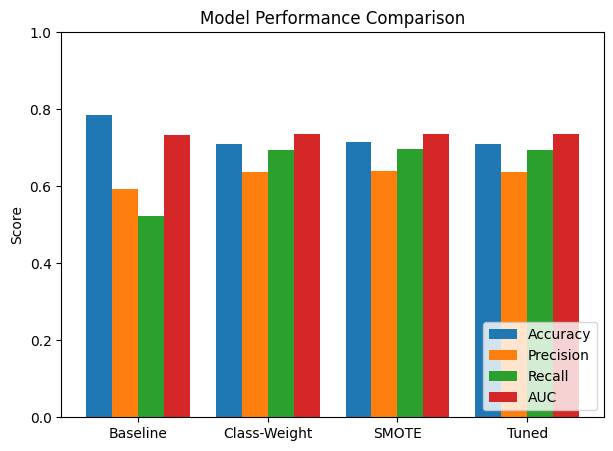

In [21]:
# Bar chart of key metrics by model
metrics = ['Accuracy', 'Precision', 'Recall', 'AUC']
x = np.arange(len(models))
width = 0.2
plt.figure(figsize=(7,5))
for i, metric in enumerate(metrics):
    values = summary[metric]
    plt.bar(x + (i-1.5)*width, values, width, label=metric)
plt.xticks(x, models)
plt.ylabel("Score")
plt.ylim(0,1.0)
plt.title("Model Performance Comparison")
plt.legend(loc='lower right')
plt.show()
